# GLM

The goal here is to model the variability in physiological data by the variability of the outdoor stimuli, which include climate, geographical and social stimuli.
A GLM will be fitted to the data. The design matrix will include rows corresponding to averages of data from 10 meter intervals. This increases SNR.

In [ ]:
# Import necessary modules
import os
from utils import *
import utils.for_setpath as path
import utils.for_empatica as empatica

# Data processing
import numpy as np
import matplotlib.pyplot as plt

# Pluma-python API  
from modules import *
from pluma.schema.outdoor import build_schema
from missing_sync import build_schema

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def average_by_gps(df, dist, plot=False, output_path=None, column_order=None):
    """
    Averages rows in the DataFrame based on the 'cum_dist' column.
    All rows whose 'cum_dist' falls into the same interval (of length `dist` meters)
    are averaged together. Optionally, the function plots a basemap of the averaged GPS
    intervals and filters the averaged DataFrame to only include a given set of columns.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing a "cum_dist" column (in meters) along with GPS and other numeric data.
    dist : float
        Distance interval in meters over which to average the data.
    plot : bool, optional
        If True, the function will generate a basemap plot showing the averaged intervals.
    output_path : str, optional
        Directory in which to save the plot if plot==True. If None, the plot is displayed.
    column_order : list, optional
        A list of column names to keep in the final averaged DataFrame.
        Only those columns from this list that exist in the averaged data will be kept.
    
    Returns:
    --------
    avg_df : pd.DataFrame
        A new DataFrame with one row per interval (with bin midpoints) and averaged values.
        The averaged cumulative distance is stored in a column named "avg_cum_dist".
    """
    # Ensure we work on a copy
    df = df.copy()
    
    if 'cum_dist' not in df.columns:
        raise ValueError("Input dataframe must contain a 'cum_dist' column.")
    
    # Create bins from 0 up to maximum cum_dist, with step = dist
    max_dist = df['cum_dist'].max()
    bins = np.arange(0, max_dist + dist, dist)
    labels = (bins[:-1] + bins[1:]) / 2  # use the midpoints as labels
    df['dist_bin'] = pd.cut(df['cum_dist'], bins=bins, labels=labels, include_lowest=True)
    print(f"[INFO] Created {len(labels)} intervals from 0 to {max_dist:.2f} m (interval = {dist} m).")
    
    # Group by the distance bin and compute the mean of numeric columns.
    avg_df = df.groupby('dist_bin').mean(numeric_only=True).reset_index()
    # Rename the averaged cum_dist to 'avg_cum_dist'
    avg_df.rename(columns={'cum_dist': 'avg_cum_dist'}, inplace=True)
    
    # Optionally filter the resulting DataFrame to only include columns in column_order.
    if column_order is not None:
        available_columns = [col for col in column_order if col in avg_df.columns]
        print(f"[INFO] Available predictor columns in the averaged data: {available_columns}")
        # Keep the bin information as well
        avg_df = avg_df[['dist_bin'] + available_columns]
    
    # If plotting is requested, plot the averaged GPS intervals on a basemap.
    if plot:
        # Check that averaged data has the required GPS coordinate columns.
        if 'longitude_corrected' in avg_df.columns and 'latitude_corrected' in avg_df.columns:
            # Create a GeoDataFrame from the averaged data.
            gdf_avg = gpd.GeoDataFrame(avg_df, geometry=gpd.points_from_xy(avg_df.longitude_corrected, avg_df.latitude_corrected), crs="EPSG:4326")
            # Convert to Web Mercator for basemap plotting.
            gdf_web = gdf_avg.to_crs(epsg=3857)
            
            # Define a helper function to add a basemap using Contextily.
            def add_basemap_to_ax(ax, data_crs="EPSG:4326", source=None):
                import contextily as ctx
                if source is None:
                    source = ctx.providers.CartoDB.Positron
                ctx.add_basemap(ax, crs=data_crs, source=source)
            
            fig, ax = plt.subplots(figsize=(10, 6))
            # Plot the averaged points.
            gdf_web.plot(ax=ax, color='red', markersize=30, alpha=0.7)
            # Add basemap (here we pass data_crs as EPSG:3857 because gdf_web is in that projection).
            add_basemap_to_ax(ax, data_crs="EPSG:3857")
            # Remove grid lines and spines for a clean look.
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_title("Averaged GPS Data Intervals", fontsize=14)
            ax.set_xlabel("Longitude", fontsize=12)
            ax.set_ylabel("Latitude", fontsize=12)
            plt.tight_layout()
            if output_path is not None:
                if not os.path.exists(output_path):
                    os.makedirs(output_path)
                plot_file = os.path.join(output_path, "average_by_gps.png")
                plt.savefig(plot_file, dpi=300, bbox_inches='tight')
                print(f"[INFO] Basemap plot saved to {plot_file}")
                plt.close(fig)
            else:
                plt.show()
        else:
            print("[WARN] 'longitude' and/or 'latitude' columns not found in averaged data; skipping basemap plot.")
    
    return avg_df

# Example predictor list
column_order = [
    'time',
    'longitude_corrected', 'latitude_corrected',
    'original_longitude', 'original_latitude', 'elevation',
    'day_of_year', 'day', 'month', 'hour', 'minute', 'second',
    'participant_id', 'session_id', 'age', 'sex',
    'utci_stress_category',
    'typology',
    'valence', 'arousal', 'naturalness', 'crowdedness',
    'air_quality_index', 'air_temperature', 'air_humidity', 'air_pressure', 'sound_pressure_level',
    'humidity_sensor', 'analog_voltage', 'pm1_0', 'pm2_5', 'pm10_0', 'solar_light', 'thermocouple_temp',
    'ptc_air_temp', 'north_wind', 'east_wind', 'gust_wind', 'atmospheric_temperature', 'temp_atmospheric',
    'temp_tk', 'temp_tk_ptc', 'radiant_temp', 'Atmosferic Pressure', 'Dew Point',
    'empatica_heart_rate', 'skin_temperature', 'eda_raw', 'eda_phasic', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'acceleration_magnitude', 'bvp',
    'delta', 'theta', 'alpha', 'beta', 'gamma', 'frontal alpha', 'frontal midline theta', 'theta-beta ratio', 'frontal alpha asymmetry', 'frontal theta'
]

my_dataframe = pd.read_csv(r"Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE008\ses-Baixa\alldata.csv")
averaged_df = average_by_gps(my_dataframe, 10, plot=True, output_path=os.path.join(path.results, "fulldata_analysis", "glm"), column_order=column_order)



In [ ]:
averaged_df

In [ ]:
import os
import re
import glob
import pandas as pd
import numpy as np
import statsmodels.api as sm

def average_by_gps(df, dist):
    """
    Averages rows in the DataFrame based on the 'cum_dist' column.
    All rows whose cum_dist falls into the same interval of length 'dist'
    are averaged together.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing a "cum_dist" column (in meters) and other numeric columns.
    dist : float
        Distance interval in meters.

    Returns:
    --------
    pd.DataFrame
        A new DataFrame with one row per interval, where each column is averaged.
        Also includes an "avg_cum_dist" column that is the mean cum_dist in the interval.
    """
    # Create bins from 0 to the maximum cumulative distance
    max_dist = df['cum_dist'].max()
    bins = np.arange(0, max_dist + dist, dist)
    # Label each bin with its midpoint (or you can choose the lower bound)
    labels = (bins[:-1] + bins[1:]) / 2

    # Create a new column with bin labels
    df = df.copy()
    df['dist_bin'] = pd.cut(df['cum_dist'], bins=bins, labels=labels, include_lowest=True)

    # Group by the distance bin and average numeric columns
    # We include "cum_dist" by taking its mean and rename it to "avg_cum_dist"
    avg_df = df.groupby('dist_bin').mean(numeric_only=True).reset_index()
    avg_df.rename(columns={'cum_dist': 'avg_cum_dist'}, inplace=True)
    # Also convert the bin label to numeric (it is a float already if labels were set)
    avg_df['dist_bin'] = avg_df['dist_bin'].astype(float)
    return avg_df

def process_all_datasets(parent_dir, dist):
    """
    Process all datasets in a folder tree. For each CSV file found under the folder
    structure (e.g., sub-OE001/ses-Belem/alldata.csv), this function reads the CSV,
    calls average_by_gps with the specified distance interval, and adds columns extracted
    from the folder names (e.g., subject code and session name).

    The processed DataFrames are concatenated into one design matrix DataFrame.

    Parameters:
    -----------
    parent_dir : str
        The parent directory containing the dataset folders.
    dist : float
        The distance interval (in meters) to average over.

    Returns:
    --------
    pd.DataFrame
        A design matrix DataFrame where each row corresponds to the average data over a
        distance interval from one session.
    """
    all_dfs = []
    # Use glob to find all CSV files (assuming the structure sub-*/ses-*/alldata.csv)
    pattern = os.path.join(parent_dir, "sub-*", "ses-*", "alldata.csv")
    file_list = glob.glob(pattern, recursive=True)
    print(f"Found {len(file_list)} dataset files.")
    for file_path in file_list:
        try:
            # Read the CSV file into a DataFrame.
            df = pd.read_csv(file_path)
            # Check that the required column exists.
            if 'cum_dist' not in df.columns:
                print(f"Skipping {file_path}: 'cum_dist' column not found.")
                continue

            # Average the data by distance interval.
            avg_df = average_by_gps(df, dist)

            # Extract subject and session information from the file path.
            # For example, if the path is: Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE001\ses-Belem\alldata.csv
            # We extract "OE001" and "Belem"
            m = re.search(r"sub-([A-Z0-9]+)", file_path, re.IGNORECASE)
            subject_code = m.group(1) if m else "Unknown"
            m2 = re.search(r"ses-([A-Za-z0-9]+)", file_path)
            session = m2.group(1) if m2 else "Unknown"
            # Add these as new columns so you can later identify each row.
            avg_df['subject_code'] = subject_code
            avg_df['session'] = session
            # Optionally, add a file identifier or city (if known from parent_dir)
            avg_df['source_file'] = os.path.basename(file_path)
            
            all_dfs.append(avg_df)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    if not all_dfs:
        print("No data processed.")
        return None
    design_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Design matrix has {design_df.shape[0]} rows and {design_df.shape[1]} columns.")
    return design_df

def fit_glm(design_df, response_var, predictors):
    """
    Fits a Generalized Linear Model (GLM) to the design matrix.
    
    Parameters:
    -----------
    design_df : pd.DataFrame
        The design matrix DataFrame with averaged rows.
    response_var : str
        The name of the dependent variable in the design matrix.
    predictors : list of str
        A list of column names to use as independent variables.
    
    Returns:
    --------
    model_fit : statsmodels.genmod.generalized_linear_model.GLMResultsWrapper
        The fitted GLM results.
    """
    # Drop rows with missing values in the selected columns
    design_df = design_df.dropna(subset=[response_var] + predictors)
    X = design_df[predictors]
    X = sm.add_constant(X)
    y = design_df[response_var]
    
    glm_model = sm.GLM(y, X, family=sm.families.Gaussian())
    model_fit = glm_model.fit()
    print(model_fit.summary())
    return model_fit

# Example usage:
if __name__ == '__main__':
    # Define the parent directory containing the fulldata folders.
    parent_directory = r"Z:\Exp_4-outdoor_walk\lisbon\results\fulldata"
    # Set the distance interval (e.g., 10 meters)
    distance_interval = 10
    # Process all datasets in the parent directory.
    design_matrix = process_all_datasets(parent_directory, distance_interval)
    
    # Suppose your design matrix has a column named 'response' (the dependent variable)
    # and other columns (e.g., average values of physiological variables) as predictors.
    # You can define the response variable and predictor columns as needed.
    if design_matrix is not None:
        # For demonstration, assume there is a column 'response' and predictors 'var1', 'var2'
        response = 'alpha'
        predictors = [
        'participant_id', 'session_id', 'age', 'sex',
        'utci_stress_category',
        'typology',
        'valence', 'arousal', 'naturalness', 'crowdedness',
        'air_quality_index', 'air_temperature', 'air_humidity', 'air_pressure', 'sound_pressure_level',
        'humidity_sensor', 'analog_voltage', 'pm1_0', 'pm2_5', 'pm10_0', 'solar_light', 'thermocouple_temp',
        'ptc_air_temp', 'north_wind', 'east_wind', 'gust_wind', 'atmospheric_temperature', 'temp_atmospheric',
        'temp_tk', 'temp_tk_ptc', 'radiant_temp', 'Atmosferic Pressure', 'Dew Point'
        ]
        # Ensure these columns exist before fitting GLM.
        if response in design_matrix.columns and all(p in design_matrix.columns for p in predictors):
            fit_glm(design_matrix, response, predictors)
        else:
            print("The required columns for GLM are not in the design matrix.")


Found 77 dataset files.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE003\ses-Belem\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE003\ses-Restauradores\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE007\ses-Graca\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE011\ses-Baixa\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE026\ses-Gulbenkian\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE028\ses-Baixa\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE029\ses-Lapa\alldata.csv: 'cum_dist' column not found.
Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE031\ses-Gulb1\alldata.csv: 'cum_dist' column not found.
Error processing Z:\Exp_4-ou

[INFO] Found 77 dataset files.
[INFO] Averaged data over 109 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 117 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 34 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 94 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 1 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 99 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 90 intervals using mean() which ignores NaN values.
[WARN] Skipping Z:\Exp_4-outdoor_walk\lisbon\results\fulldata\sub-OE003\ses-Belem\alldata.csv: 'cum_dist' column not found.
[INFO] Averaged data over 115 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 48 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 134 intervals using mean() which ignores NaN values.
[INFO] Averaged data over 70 intervals using mean() which igno

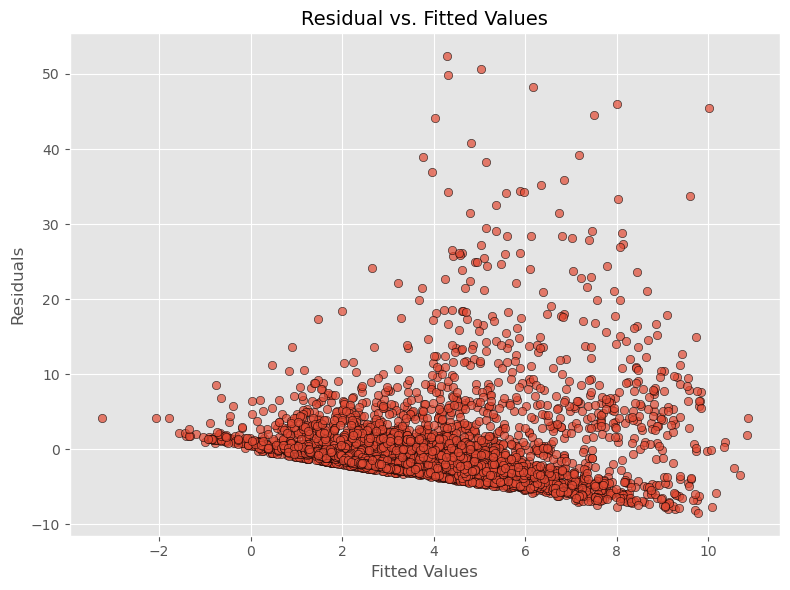

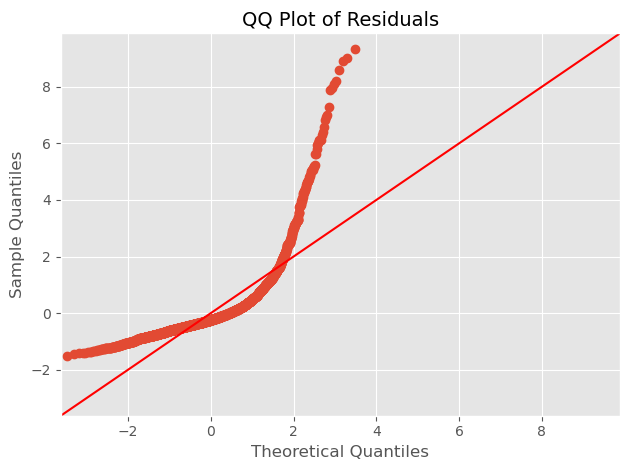

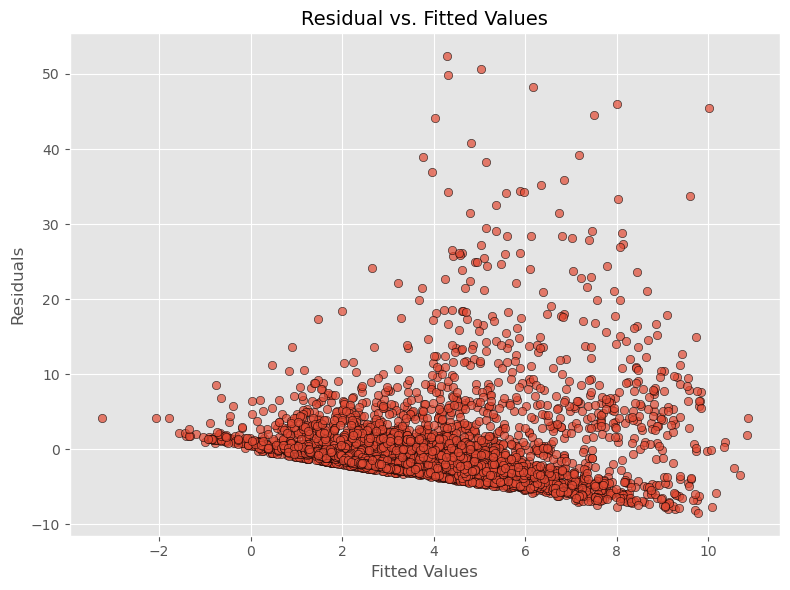

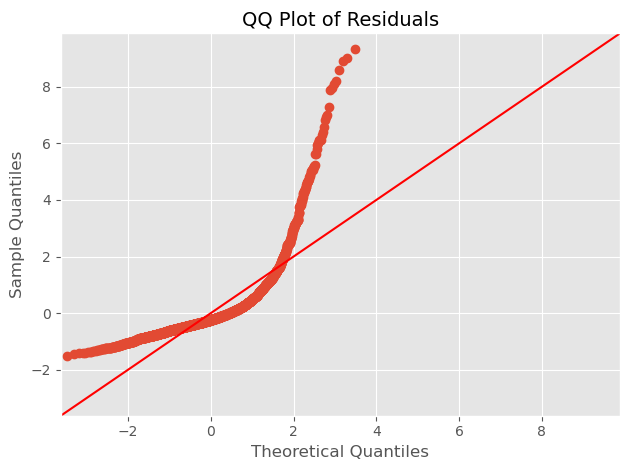

In [22]:
import os
import re
import glob
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def average_by_gps(df, dist):
    """
    Averages rows in the DataFrame based on the 'cum_dist' column.
    All rows whose cum_dist falls into the same interval of length 'dist'
    are averaged together.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing a "cum_dist" column (in meters) and other numeric columns.
    dist : float
        Distance interval in meters.
    
    Returns:
    --------
    pd.DataFrame
        A new DataFrame with one row per interval, where each column is averaged.
        Also includes an "avg_cum_dist" column that is the mean cum_dist in the interval.
    
    Note:
    -----
    The pandas groupby().mean(numeric_only=True) function ignores NaN values by default.
    """
    # Create bins from 0 to the maximum cumulative distance.
    max_dist = df['cum_dist'].max()
    bins = np.arange(0, max_dist + dist, dist)
    # Use the midpoints as labels.
    labels = (bins[:-1] + bins[1:]) / 2

    df = df.copy()
    df['dist_bin'] = pd.cut(df['cum_dist'], bins=bins, labels=labels, include_lowest=True)

    # Group by the distance bin and compute the mean for numeric columns.
    avg_df = df.groupby('dist_bin').mean(numeric_only=True).reset_index()
    # Rename the averaged 'cum_dist' to 'avg_cum_dist'
    avg_df.rename(columns={'cum_dist': 'avg_cum_dist'}, inplace=True)
    avg_df['dist_bin'] = avg_df['dist_bin'].astype(float)
    
    print(f"[INFO] Averaged data over {len(labels)} intervals using mean() which ignores NaN values.")
    return avg_df

def process_all_datasets(parent_dir, dist):
    """
    Process all datasets in a folder tree. For each CSV file found under the folder
    structure (e.g., sub-OE001/ses-Belem/alldata.csv), this function reads the CSV,
    calls average_by_gps with the specified distance interval, and adds columns extracted
    from the folder names (e.g., subject code and session name).
    
    The processed DataFrames are concatenated into one design matrix DataFrame.
    
    Parameters:
    -----------
    parent_dir : str
        The parent directory containing the dataset folders.
    dist : float
        The distance interval (in meters) to average over.
    
    Returns:
    --------
    pd.DataFrame
        A design matrix DataFrame where each row corresponds to the average data over a
        distance interval from one session.
    """
    all_dfs = []
    pattern = os.path.join(parent_dir, "sub-*", "ses-*", "alldata.csv")
    file_list = glob.glob(pattern, recursive=True)
    print(f"[INFO] Found {len(file_list)} dataset files.")
    
    for file_path in file_list:
        try:
            df = pd.read_csv(file_path)
            if 'cum_dist' not in df.columns:
                print(f"[WARN] Skipping {file_path}: 'cum_dist' column not found.")
                continue

            avg_df = average_by_gps(df, dist)
            m = re.search(r"sub-([A-Z0-9]+)", file_path, re.IGNORECASE)
            subject_code = m.group(1) if m else "Unknown"
            m2 = re.search(r"ses-([A-Za-z0-9]+)", file_path)
            session = m2.group(1) if m2 else "Unknown"
            avg_df['subject_code'] = subject_code
            avg_df['session'] = session
            avg_df['source_file'] = os.path.basename(file_path)
            all_dfs.append(avg_df)
        except Exception as e:
            print(f"[ERROR] Error processing {file_path}: {e}")
    
    if not all_dfs:
        print("[ERROR] No data processed.")
        return None
    design_df = pd.concat(all_dfs, ignore_index=True)
    print(f"[INFO] Design matrix has {design_df.shape[0]} rows and {design_df.shape[1]} columns.")
    return design_df

def fit_glm(design_df, response_var, predictors):
    """
    Fits a Generalized Linear Model (GLM) to the design matrix.
    
    Parameters:
    -----------
    design_df : pd.DataFrame
        The design matrix DataFrame with averaged rows.
    response_var : str
        The name of the dependent variable in the design matrix.
    predictors : list of str
        A list of column names to use as independent variables.
    
    Returns:
    --------
    model_fit : statsmodels.genmod.generalized_linear_model.GLMResultsWrapper
        The fitted GLM results.
    """
    # Columns we need to check for missing values
    cols_to_check = [response_var] + predictors
    total_rows = design_df.shape[0]
    print("[DEBUG] Missing values for GLM columns:")
    for col in cols_to_check:
        if col in design_df.columns:
            n_missing = design_df[col].isna().sum()
            pct_missing = (n_missing / total_rows) * 100
            print(f"  {col}: {n_missing} missing out of {total_rows} rows ({pct_missing:.1f}%)")
        else:
            print(f"  {col}: Column not found!")
    
    # Drop rows with missing values in the required columns
    design_df_clean = design_df.dropna(subset=cols_to_check)
    print(f"[INFO] GLM: {design_df_clean.shape[0]} rows remain after dropping missing values.")
    
    # Check if any rows remain
    if design_df_clean.shape[0] == 0:
        raise ValueError("No rows remain after dropping missing values; please check the input columns.")
    
    X = design_df_clean[predictors]
    X = sm.add_constant(X)
    y = design_df_clean[response_var]
    
    glm_model = sm.GLM(y, X, family=sm.families.Gaussian())
    model_fit = glm_model.fit()
    print(model_fit.summary())
    
    # Plot diagnostic plots
    # 1. Residual vs. Fitted
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(model_fit.fittedvalues, model_fit.resid_response, alpha=0.7, edgecolor='k')
    ax.set_xlabel("Fitted Values", fontsize=12)
    ax.set_ylabel("Residuals", fontsize=12)
    ax.set_title("Residual vs. Fitted Values", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 2. QQ Plot of Residuals
    fig = sm.qqplot(model_fit.resid_response, line='45', fit=True)
    plt.title("QQ Plot of Residuals", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return model_fit


# Example usage:
if __name__ == '__main__':
    parent_directory = r"Z:\Exp_4-outdoor_walk\lisbon\results\fulldata"
    distance_interval = 10
    design_matrix = process_all_datasets(parent_directory, distance_interval)
    
    # Define response and predictor columns.
    response = 'alpha'
    predictors = [
        'participant_id', 'session_id', 'age', 'sex',
        # 'utci_stress_category',
        'typology',
        'valence', 'arousal', 'naturalness', 'crowdedness',
        'air_quality_index', 'air_temperature', 'air_humidity', 'air_pressure', 'sound_pressure_level',
        'humidity_sensor', 'analog_voltage', 'pm1_0', 'pm2_5', 'pm10_0', 'solar_light', 'thermocouple_temp',
        'ptc_air_temp', 'north_wind', 'east_wind', 'gust_wind', 'atmospheric_temperature', 'temp_atmospheric',
        'temp_tk', 'temp_tk_ptc', 'radiant_temp', 'Atmosferic Pressure', 'Dew Point'
    ]
    # Only keep predictors that are present in the design matrix.
    available_predictors = [p for p in predictors if p in design_matrix.columns]
    print(f"[INFO] Using predictors: {available_predictors}")
    
    if response in design_matrix.columns and available_predictors:
        glm_results = fit_glm(design_matrix, response, available_predictors)
        
        # GLM Diagnostic Plots:
        # 1. Residual vs. Fitted Plot.
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(glm_results.fittedvalues, glm_results.resid_response, alpha=0.7, edgecolor='k')
        ax.set_xlabel("Fitted Values", fontsize=12)
        ax.set_ylabel("Residuals", fontsize=12)
        ax.set_title("Residual vs. Fitted Values", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # 2. QQ Plot of Residuals.
        fig = sm.qqplot(glm_results.resid_response, line='45', fit=True)
        plt.title("QQ Plot of Residuals", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("[ERROR] The required columns for GLM are not present in the design matrix.")
